In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
# from matplotlib.pyplot import MultipleLocator
# import os
# os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ.get("PATH","")
# matplotlib.rcParams['mathtext.fontset'] = 'custom'
# matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
# matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
# matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "sans-serif",
#     "font.sans-serif": ["Computer Modern Roman"]})



FileNotFoundError: [Errno 2] No such file or directory: './assimilation/data/lambda_scan_parameter_grid/a_5p000e00__nudge_iters_020/lambda_scan/runs/lambda_002_1p000e-07/x_da_kdenudge_1d_seed0.npz'

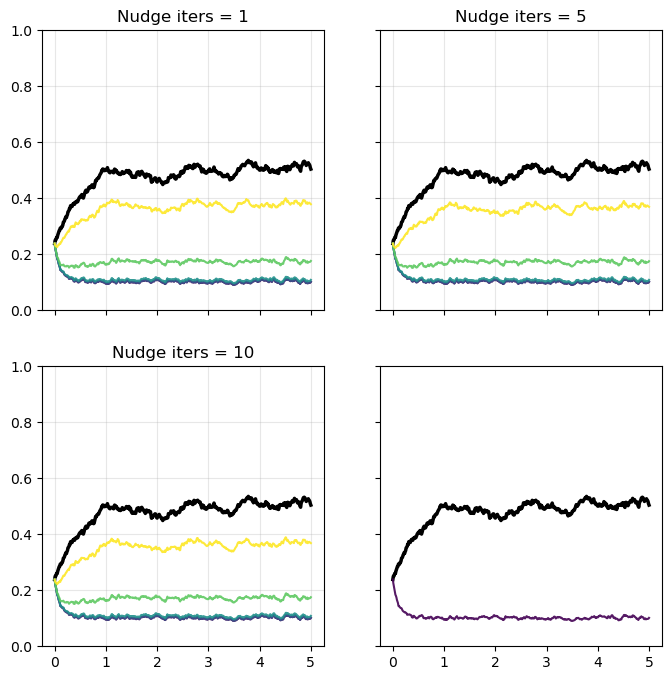

In [7]:
nudge_list = [1, 5, 10, 20]
lambda_list = [
    ("001_0p000e00", "0"),
    ("002_1p000e-07", "1e-7"),
    ("003_1p000e-06", "1e-6"),
    ("004_1p000e-05", "1e-5"),
    ("005_1p000e-04", "1e-4"),
]

# 真值（只需要读一次）
data_true = np.load("./simulation/data/mv_sim_seed0.npz")
times = data_true["times"]
var_true = np.var(data_true["x_paths"], axis=-1)

# colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(lambda_list)))

fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, nudge in enumerate(nudge_list):
    ax = axes[idx]

    # 画真值
    ax.plot(times, var_true, color='black', linewidth=2.5, label='True')

    # 画不同 lambda
    for (lam_str, lam_label), c in zip(lambda_list, colors):
        path = f"./assimilation/data/lambda_scan_parameter_grid/a_5p000e00__nudge_iters_{nudge:03d}/lambda_scan/runs/lambda_{lam_str}/x_da_kdenudge_1d_seed0.npz"
        data = np.load(path)
        var_est = np.var(data["x_est"], axis=-1)

        ax.plot(times, var_est, color=c, alpha=0.9, label=f"$\\lambda={lam_label}$")
    ax.set_ylim([0,1])
    ax.set_title(f"Nudge iters = {nudge}")
    ax.grid(alpha=0.3)

# 统一 legend（避免重复）
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=6)

fig.supxlabel("Time")
fig.supylabel("Variance")
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [ ]:
data =  np.load("./assimilation/data/lambda_scan/runs/lambda_001_0p000e00/x_da_kdenudge_1d_seed0.npz")

x = data["x_est"]
bins = np.linspace(x.min(), x.max(), 100)
hist_time = []

for t in range(x.shape[0]):
    hist, _ = np.histogram(x[t, :], bins=bins, density=True)
    hist_time.append(hist)

hist_time = np.array(hist_time)

plt.imshow(hist_time, aspect='auto', origin='lower',
           extent=[bins[0], bins[-1], 0, x.shape[0]])
plt.colorbar(label="density")
plt.xlabel("x")
plt.ylabel("time")
plt.title("Density evolution")
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

data = np.load("../case1d/assimilation/data/lambda_scan_parameter_grid/a_5p000e-01__nudge_iters_010/lambda_scan/runs/lambda_004_1p000e-05/x_da_kdenudge_1d_seed0.npz")
x = data["x_est"]

# evaluation grid（比 histogram 更密一点）
x_grid = np.linspace(-1, 1, 200)

kde_time = []

for t in range(x.shape[0]):
    kde = gaussian_kde(x[t, :])
    density = kde(x_grid)
    kde_time.append(density)

kde_time = np.array(kde_time)

plt.imshow(
    kde_time,
    aspect='auto',
    origin='lower',
    extent=[x_grid[0], x_grid[-1], 0, x.shape[0]]
)
plt.colorbar(label="density")
plt.xlabel("x")
plt.ylabel("time")
plt.title("Density evolution (KDE)")
plt.show()

ModuleNotFoundError: No module named 'scipy'

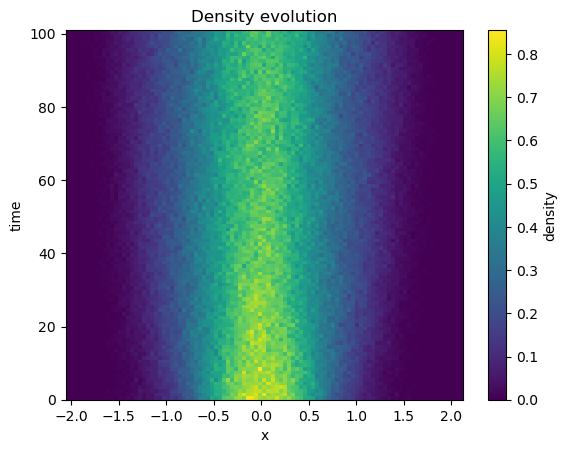

In [81]:
data =  np.load("./assimilation/data/lambda_scan/runs/lambda_003_1p000e-06/x_da_kdenudge_1d_seed0.npz")
x = data["x_est"]
bins = np.linspace(x.min(), x.max(), 100)
hist_time = []

for t in range(x.shape[0]):
    hist, _ = np.histogram(x[t, :], bins=bins, density=True)
    hist_time.append(hist)

hist_time = np.array(hist_time)

plt.imshow(hist_time, aspect='auto', origin='lower',
           extent=[bins[0], bins[-1], 0, x.shape[0]])
plt.colorbar(label="density")
plt.xlabel("x")
plt.ylabel("time")
plt.title("Density evolution")
plt.show()

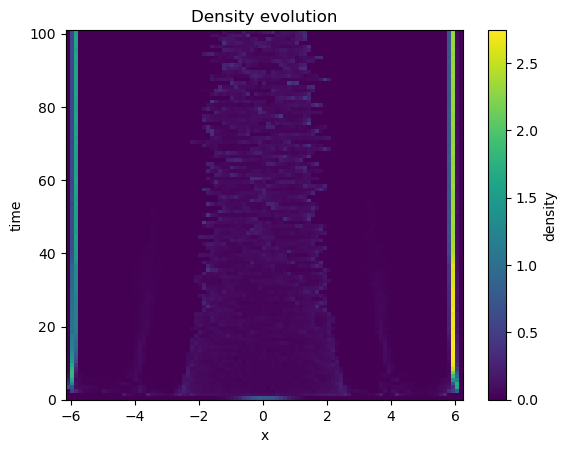

In [82]:
data =  np.load("./assimilation/data/lambda_scan/runs/lambda_004_1p000e-05/x_da_kdenudge_1d_seed0.npz")
x = data["x_est"]
bins = np.linspace(x.min(), x.max(), 100)
hist_time = []

for t in range(x.shape[0]):
    hist, _ = np.histogram(x[t, :], bins=bins, density=True)
    hist_time.append(hist)

hist_time = np.array(hist_time)

plt.imshow(hist_time, aspect='auto', origin='lower',
           extent=[bins[0], bins[-1], 0, x.shape[0]])
plt.colorbar(label="density")
plt.xlabel("x")
plt.ylabel("time")
plt.title("Density evolution")
plt.show()